# Shipment Attributes — Data-Quality Audit (Issue #7, parent #2)

Scope (from `data/data_dictionary.md` → *Shipment attributes*): `shipment_mode`, `carrier`, `service_level`,
`origin_metro`, `dest_metro`, `origin_zip`, `dest_zip`, `origin_lat/lon`, `dest_lat/lon`, `distance_miles`, `zone`.

Goal: find the deliberate data-quality issues in these columns, quantify them, and provide a reusable
`clean_shipment_attributes(df)` function. Only `train.csv` is used — `test.csv` is held out as unseen
real-world data for the finished model and is not opened here. Raw CSVs are never modified.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path("../data") if Path("../data").exists() else Path("data")

SHIP_COLS = ["shipment_mode", "carrier", "service_level", "origin_metro", "dest_metro",
             "origin_zip", "dest_zip", "origin_lat", "origin_lon", "dest_lat", "dest_lon",
             "distance_miles", "zone"]

## 1. Load

In [2]:
raw = pd.read_csv(DATA / "train.csv")
print(raw.shape)
raw[SHIP_COLS].dtypes

(40030, 33)


shipment_mode         str
carrier               str
service_level         str
origin_metro          str
dest_metro            str
origin_zip          int64
dest_zip            int64
origin_lat        float64
origin_lon        float64
dest_lat          float64
dest_lon          float64
distance_miles    float64
zone                int64
dtype: object

In [3]:
raw[SHIP_COLS].isna().sum()

shipment_mode     0
carrier           0
service_level     0
origin_metro      0
dest_metro        0
origin_zip        0
dest_zip          0
origin_lat        0
origin_lon        0
dest_lat          0
dest_lon          0
distance_miles    0
zone              0
dtype: int64

No nulls in any shipment-attribute column; the issues here are formatting/encoding, not missingness.

## 2. Duplicate rows (context)

Owned by the Identifiers sub-issue, but de-duplicating first keeps the counts below honest.

In [4]:
n_dup_rows = raw.duplicated().sum()
n_dup_ids = raw["shipment_id"].duplicated().sum()
print(f"{n_dup_rows} exact duplicate rows, {n_dup_ids} duplicate shipment_ids, "
      f"all exact copies = {n_dup_rows == n_dup_ids}")

dedup = raw.drop_duplicates().reset_index(drop=True)
len(dedup)

81 exact duplicate rows, 81 duplicate shipment_ids, all exact copies = True


39949

## 3. Categorical noise: `carrier`, `service_level`, `shipment_mode`

`repr()` makes leading/trailing whitespace visible.

In [5]:
for col in ["shipment_mode", "carrier", "service_level"]:
    vc = dedup[col].map(repr).value_counts()
    print(f"--- {col}: {len(vc)} raw variants")
    print(vc.to_string(), end="\n\n")

--- shipment_mode: 2 raw variants
shipment_mode
'parcel'         34042
'ltl_freight'     5907

--- carrier: 24 raw variants
carrier
'Falcon Post'            12924
'Northstar Parcel'       10874
'Summit Express'          7638
'Ironclad Freight'        3397
'Vela Freight'            2276
'Cobalt Regional'         1250
'FALCON POST'              215
'NORTHSTAR PARCEL'         210
'falcon post'              169
'  Falcon Post '           156
'  Northstar Parcel '      137
'northstar parcel'         117
'SUMMIT EXPRESS'           115
'  Summit Express '         94
'summit express'            90
'  Ironclad Freight '       59
'IRONCLAD FREIGHT'          53
'ironclad freight'          44
'VELA FREIGHT'              39
'  Vela Freight '           27
'COBALT REGIONAL'           22
'  Cobalt Regional '        16
'cobalt regional'           15
'vela freight'              12

--- service_level: 24 raw variants
service_level
'Ground'               18094
'Expedited'             6570
'TwoDay'        

In [6]:
CARRIERS = ["Falcon Post", "Summit Express", "Northstar Parcel", "Cobalt Regional",
            "Ironclad Freight", "Vela Freight"]
SERVICE_LEVELS = ["Ground", "Expedited", "TwoDay", "Overnight", "LTL Standard", "LTL Guaranteed"]
MODES = ["parcel", "ltl_freight"]

CANONICAL = {
    "carrier": {v.lower(): v for v in CARRIERS},
    "service_level": {v.lower(): v for v in SERVICE_LEVELS},
    "shipment_mode": {v.lower(): v for v in MODES},
}

def canonicalize(s, mapping):
    """Strip whitespace, then match case-insensitively to the canonical spelling."""
    return s.str.strip().str.lower().map(mapping)

rows = []
for col, mapping in CANONICAL.items():
    clean_col = canonicalize(dedup[col], mapping)
    assert clean_col.notna().all(), f"unmapped {col} values"
    noisy = dedup[col] != clean_col
    ws = dedup[col] != dedup[col].str.strip()
    rows.append({"column": col, "raw_variants": dedup[col].nunique(),
                 "clean_values": clean_col.nunique(), "noisy_rows": noisy.sum(),
                 "whitespace_rows": ws.sum(), "case_only_rows": (noisy & ~ws).sum(),
                 "pct_noisy": round(100 * noisy.mean(), 2)})
cat_report = pd.DataFrame(rows).set_index("column")
cat_report

,raw_variants,clean_values,noisy_rows,whitespace_rows,case_only_rows,pct_noisy
column,,,,,,
carrier,24,6,1590,489,1101,3.98
service_level,24,6,1554,492,1062,3.89
shipment_mode,2,2,0,0,0,0.00


**Finding:** `carrier` and `service_level` each have 24 raw variants that collapse to exactly 6 canonical values
(UPPER, lower, and `"  Name "` padding). `shipment_mode` is clean. Every value maps — nothing unknown.

## 4. Malformed ZIPs

In [7]:
for col in ["origin_zip", "dest_zip"]:
    lengths = dedup[col].astype(str).str.len().value_counts().sort_index().to_dict()
    print(f"{col}: dtype={dedup[col].dtype}, digit-length counts={lengths}")

origin_zip: dtype=int64, digit-length counts={4: 1933, 5: 38016}
dest_zip: dtype=int64, digit-length counts={4: 1935, 5: 38014}


In [8]:
# Which metros do the short ZIPs belong to?
for side in ["origin", "dest"]:
    short = dedup[f"{side}_zip"].astype(str).str.len() < 5
    print(side, dedup.loc[short, f"{side}_metro"].value_counts().to_dict())
    print("  sample:", dedup.loc[short, f"{side}_zip"].head(5).tolist())

origin {'Boston MA': 1933}
  sample: [2199, 2121, 2132, 2189, 2131]
dest {'Boston MA': 1935}
  sample: [2182, 2170, 2110, 2114, 2165]


In [9]:
def fix_zip(s):
    return s.astype("Int64").astype(str).str.zfill(5)

# Each metro should map to a single ZIP-3 prefix once fixed
prefix_check = {}
for side in ["origin", "dest"]:
    z = fix_zip(dedup[f"{side}_zip"])
    assert z.str.fullmatch(r"\d{5}").all()
    prefix_check[side] = dedup.assign(zip3=z.str[:3]).groupby(f"{side}_metro")["zip3"].unique()
pd.DataFrame(prefix_check)

,origin,dest
Atlanta GA,[303],[303]
Boston MA,[021],[021]
Charlotte NC,[282],[282]
Chicago IL,[606],[606]
Columbus OH,[432],[432]
Dallas TX,[752],[752]
Denver CO,[802],[802]
Houston TX,[770],[770]
Kansas City MO,[641],[641]
Los Angeles CA,[900],[900]


**Finding:** ZIPs are parsed as `int64`, so every **Boston MA** ZIP (`021xx`) lost its leading zero → 4 digits.
It's the only metro with a leading-zero ZIP. Fix: treat as string and `zfill(5)`. After fixing, every metro maps
to exactly one ZIP-3 prefix (no cross-metro ZIP errors). ZIPs should be treated as **categorical identifiers**,
not numbers, in any model.

## 5. Cross-field consistency checks

In [10]:
PARCEL_CARRIERS = {"Falcon Post", "Summit Express", "Northstar Parcel", "Cobalt Regional"}
PARCEL_SERVICES = {"Ground", "Expedited", "TwoDay", "Overnight"}
WEST_MOUNTAIN = {"Los Angeles CA", "Phoenix AZ", "Seattle WA", "Denver CO", "Portland OR", "Salt Lake City UT"}
EARTH_RADIUS_MI = 3958.8

def haversine_miles(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * EARTH_RADIUS_MI * np.arcsin(np.sqrt(a))

def consistency_checks(df):
    """Return {check: n_violations}. Expects canonical carrier/service_level."""
    parcel = df["shipment_mode"] == "parcel"
    dist_calc = haversine_miles(df["origin_lat"], df["origin_lon"], df["dest_lat"], df["dest_lon"])
    zone_ranges = df.groupby("zone")["distance_miles"].agg(["min", "max"]).sort_index()
    cobalt = df["carrier"] == "Cobalt Regional"
    return {
        "carrier vs mode": (parcel != df["carrier"].isin(PARCEL_CARRIERS)).sum(),
        "service vs mode": (parcel != df["service_level"].isin(PARCEL_SERVICES)).sum(),
        "Cobalt off west/mountain lanes": (cobalt & ~(df["origin_metro"].isin(WEST_MOUNTAIN)
                                                      & df["dest_metro"].isin(WEST_MOUNTAIN))).sum(),
        "metro with >1 origin coord": (df.groupby("origin_metro")[["origin_lat", "origin_lon"]].nunique() > 1).any(axis=1).sum(),
        "metro with >1 dest coord": (df.groupby("dest_metro")[["dest_lat", "dest_lon"]].nunique() > 1).any(axis=1).sum(),
        "distance off haversine >1%": (abs(df["distance_miles"] / dist_calc - 1) > 0.01).sum(),
        "lane with >1 distance": (df.groupby(["origin_metro", "dest_metro"])["distance_miles"].nunique() > 1).sum(),
        "overlapping zone ranges": (zone_ranges["min"].iloc[1:].values <= zone_ranges["max"].iloc[:-1].values).sum(),
        "origin == dest metro": (df["origin_metro"] == df["dest_metro"]).sum(),
    }

checked = dedup.copy()
for col, mapping in CANONICAL.items():
    checked[col] = canonicalize(checked[col], mapping)
pd.Series(consistency_checks(checked), name="violations")

carrier vs mode                   0
service vs mode                   0
Cobalt off west/mountain lanes    0
metro with >1 origin coord        0
metro with >1 dest coord          0
distance off haversine >1%        0
lane with >1 distance             0
overlapping zone ranges           0
origin == dest metro              0
Name: violations, dtype: int64

In [11]:
print("unique lanes:", checked.groupby(["origin_metro", "dest_metro"]).ngroups, "(overview says 306)")
print("metros:", checked["origin_metro"].nunique(), "origin /", checked["dest_metro"].nunique(), "dest")
checked.groupby("zone")["distance_miles"].agg(["min", "max", "count"])

unique lanes: 306 (overview says 306)
metros: 18 origin / 18 dest


,min,max,count
zone,,,
2,146.0,146.0,167
3,190.4,276.1,1529
4,333.8,588.8,4664
5,606.7,998.5,11882
6,1005.3,1390.9,7786
7,1417.3,1778.6,6565
8,1833.6,2731.8,7356


**Finding:** all cross-field relationships are internally consistent — carriers and service levels never
cross modes, Cobalt Regional only runs west/mountain lanes, each metro has one coordinate pair, `distance_miles`
matches great-circle distance within 0.05%, each lane has one distance, zones are monotone non-overlapping
distance bands, and there are exactly 306 lanes across 18 metros. No fixes needed here.

## 6. Distributions

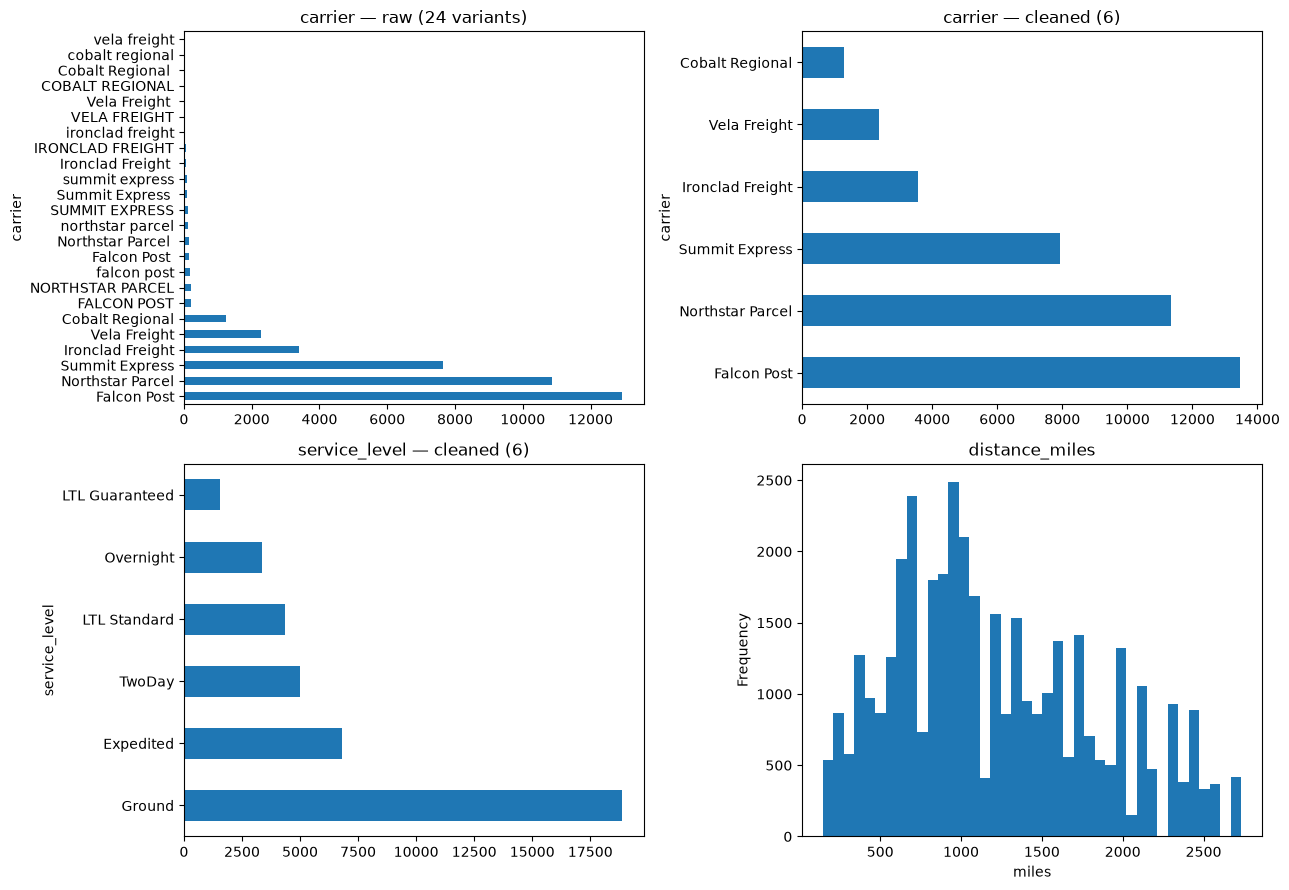

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

dedup["carrier"].value_counts().plot.barh(ax=axes[0, 0], title=f"carrier — raw ({dedup['carrier'].nunique()} variants)")
checked["carrier"].value_counts().plot.barh(ax=axes[0, 1], title="carrier — cleaned (6)")
checked["service_level"].value_counts().plot.barh(ax=axes[1, 0], title="service_level — cleaned (6)")
checked["distance_miles"].plot.hist(bins=40, ax=axes[1, 1], title="distance_miles")
axes[1, 1].set_xlabel("miles")
plt.tight_layout()
plt.show()

In [13]:
pd.crosstab(checked["carrier"], checked["service_level"])

service_level,Expedited,Ground,LTL Guaranteed,LTL Standard,Overnight,TwoDay
carrier,,,,,,
Cobalt Regional,276,717,0,0,125,185
Falcon Post,2671,7448,0,0,1349,1996
Ironclad Freight,0,0,915,2638,0,0
Northstar Parcel,2235,6320,0,0,1122,1661
Summit Express,1640,4376,0,0,771,1150
Vela Freight,0,0,627,1727,0,0


## 7. Reusable cleaner

Idempotent and row-wise (no statistics learned from the data), so it can be applied to the train /
validation / test slices of `train.csv` after the team's split — and later to `test.csv` — without leakage.
Does **not** de-duplicate; that's handled with the Identifiers checks.

In [14]:
def clean_shipment_attributes(df):
    """Fix shipment-attribute noise: categorical casing/whitespace and lost-leading-zero ZIPs."""
    df = df.copy()
    for col, mapping in CANONICAL.items():
        df[col] = canonicalize(df[col].astype(str), mapping)
        if df[col].isna().any():
            raise ValueError(f"unrecognized {col} values after cleaning")
    for col in ["origin_zip", "dest_zip"]:
        df[col] = fix_zip(df[col])
    return df

clean = clean_shipment_attributes(dedup)

assert set(clean["carrier"]) == set(CARRIERS)
assert set(clean["service_level"]) == set(SERVICE_LEVELS)
assert set(clean["shipment_mode"]) == set(MODES)
for col in ["origin_zip", "dest_zip"]:
    assert clean[col].str.fullmatch(r"\d{5}").all()
assert all(v == 0 for v in consistency_checks(clean).values())
assert clean.equals(clean_shipment_attributes(clean)), "cleaner is not idempotent"
print(f"all checks pass ({len(clean)} rows)")

all checks pass (39949 rows)


## 8. Summary (for Issue #7)

In [15]:
def n_short_zip(col):
    return int((dedup[col].astype(str).str.len() < 5).sum())

summary = pd.DataFrame([
    {"issue": "Casing/whitespace noise", "column": "carrier",
     "rows": int(cat_report.loc["carrier", "noisy_rows"]),
     "fix": "strip + case-insensitive map to 6 canonical names"},
    {"issue": "Casing/whitespace noise", "column": "service_level",
     "rows": int(cat_report.loc["service_level", "noisy_rows"]),
     "fix": "strip + case-insensitive map to 6 canonical names"},
    {"issue": "Lost leading zero (Boston MA)", "column": "origin_zip",
     "rows": n_short_zip("origin_zip"), "fix": "treat as string, zfill(5)"},
    {"issue": "Lost leading zero (Boston MA)", "column": "dest_zip",
     "rows": n_short_zip("dest_zip"), "fix": "treat as string, zfill(5)"},
    {"issue": "Exact duplicate rows (context)", "column": "all",
     "rows": int(raw.duplicated().sum()), "fix": "drop_duplicates (Identifiers sub-issue)"},
    {"issue": "None found", "column": "shipment_mode, metros, lat/lon, distance_miles, zone",
     "rows": 0, "fix": "—"},
])
summary["pct_of_rows"] = (100 * summary["rows"] / len(dedup)).round(2)
summary

,issue,column,rows,fix,pct_of_rows
0,Casing/whitespace noise,carrier,1590,strip + case-insensitive map to 6 canonical names,3.98
1,Casing/whitespace noise,service_level,1554,strip + case-insensitive map to 6 canonical names,3.89
2,Lost leading zero (Boston MA),origin_zip,1933,"treat as string, zfill(5)",4.84
3,Lost leading zero (Boston MA),dest_zip,1935,"treat as string, zfill(5)",4.84
4,Exact duplicate rows (context),all,81,drop_duplicates (Identifiers sub-issue),0.20
5,None found,"shipment_mode, metros, lat/lon, distance_miles...",0,—,0.00
